<a href="https://colab.research.google.com/github/huamanchristian44/Lab08/blob/develop/Laboratorio_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Laboratorio 08 : Árboles de decisión**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

a. Lea la base de datos, realice imputaciones, tratamiento de outliers, transformaciones de datos
y desbalance de clases en caso sea necesario. Además, separe la variable de clasificación del
resto de variables para luego obtener los datos de entrenamiento y prueba, tomando de este
último el 25% de datos.

In [ ]:
#Cargando datos desde el URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"
columns = ["ID", "Clump_Thickness", "Uniformity_Cell_Size", "Uniformity_Cell_Shape",
           "Marginal_Adhesion", "Single_Epithelial_Cell_Size", "Bare_Nuclei",
           "Bland_Chromatin", "Normal_Nucleoli", "Mitoses", "Class"]
df = pd.read_csv(url, names=columns)

In [ ]:
#Reemplazando '?' por NaN y convertir Bare_Nuclei a numérico
df.replace('?', np.nan, inplace=True)
df['Bare_Nuclei'] = pd.to_numeric(df['Bare_Nuclei'])

In [ ]:
#Imputación de valores faltantes (mediana)
imputer = SimpleImputer(strategy="median")
df.iloc[:, 1:-1] = imputer.fit_transform(df.iloc[:, 1:-1])

In [ ]:
#Eliminando columna ID
df.drop("ID", axis=1, inplace=True)

In [ ]:
#Verificando desbalance de clases
print(df["Class"].value_counts())

Class
2    458
4    241
Name: count, dtype: int64


In [ ]:
#Reemplazando clase 2 (benigno) y 4 (maligno) por 0 y 1
df["Class"] = df["Class"].map({2: 0, 4: 1})

In [ ]:
#Separando variables predictoras y target
X = df.drop("Class", axis=1)
y = df["Class"]

In [ ]:
#Dividiendo en train y test (75% - 25%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

b. Genere el modelo de árbol de decisión para clasificación y la profundidad adecuada para este.
Además, calcule las métricas de clasificación e interprete sus resultados más importantes.

In [ ]:
#Entrenando modelo de árbol de decisión
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
#Predicciones
y_pred_tree = tree.predict(X_test)

In [ ]:
#Evaluación
print("=== Árbol de Decisión ===")
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))
print("Accuracy:", accuracy_score(y_test, y_pred_tree))

=== Árbol de Decisión ===
[[110   5]
 [  7  53]]
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       115
           1       0.91      0.88      0.90        60

    accuracy                           0.93       175
   macro avg       0.93      0.92      0.92       175
weighted avg       0.93      0.93      0.93       175

Accuracy: 0.9314285714285714


c. Genere el modelo de bosques aleatorios para clasificación. Además, calcule las métricas de
clasificación y compárelas con las del árbol de clasificación. ¿Hubo mejoras o no?


In [ ]:
#Entrenando modelo de Random Forest
forest = RandomForestClassifier(n_estimators=100, random_state=42)
forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
#Predicciones
y_pred_forest = forest.predict(X_test)

In [ ]:
#Evaluación
print("=== Bosques Aleatorios ===")
print(confusion_matrix(y_test, y_pred_forest))
print(classification_report(y_test, y_pred_forest))
print("Accuracy:", accuracy_score(y_test, y_pred_forest))

=== Bosques Aleatorios ===
[[112   3]
 [  5  55]]
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       115
           1       0.95      0.92      0.93        60

    accuracy                           0.95       175
   macro avg       0.95      0.95      0.95       175
weighted avg       0.95      0.95      0.95       175

Accuracy: 0.9542857142857143


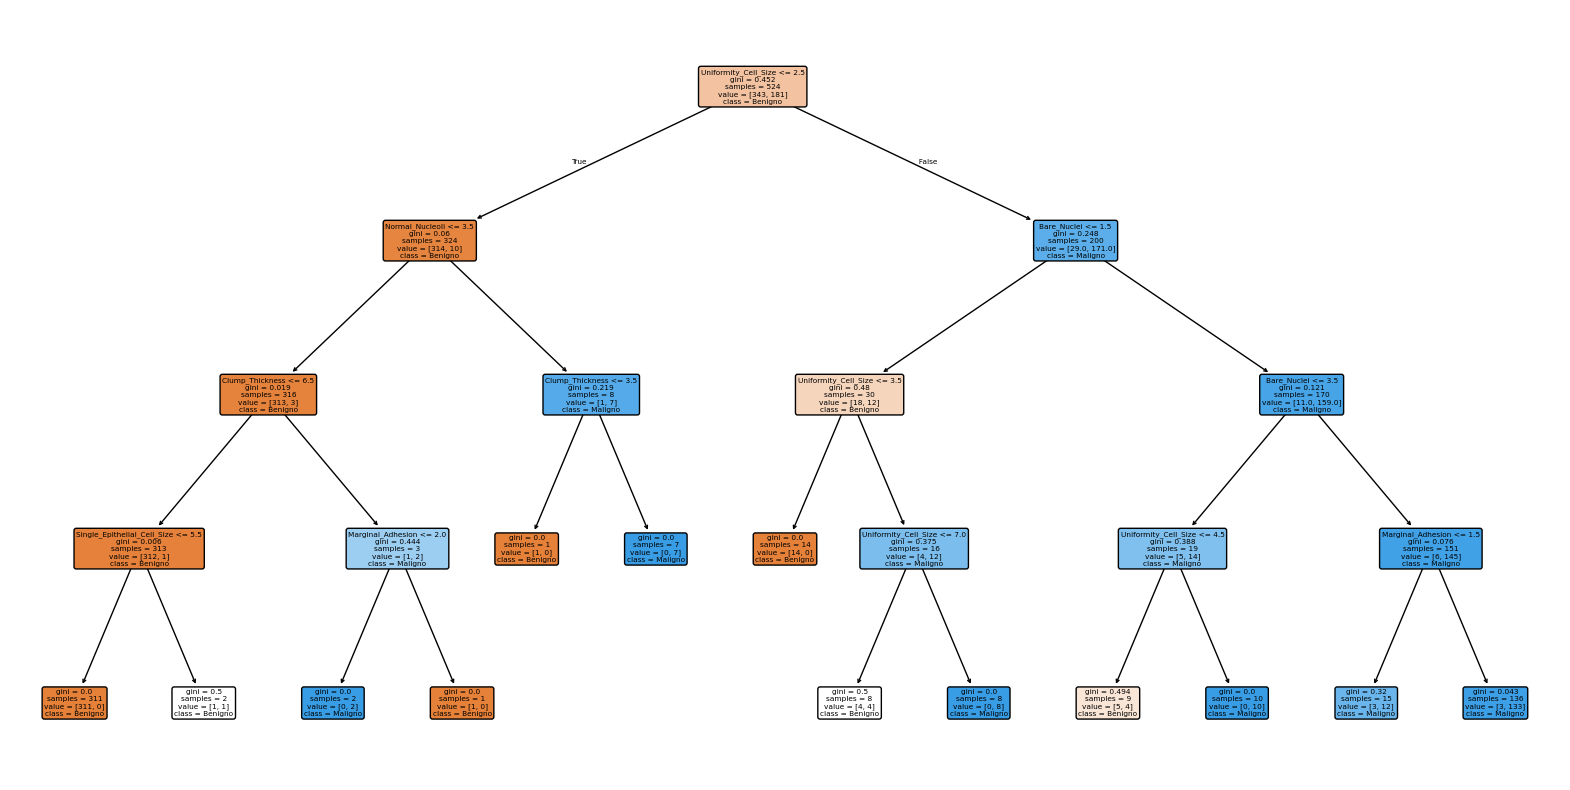

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(tree, feature_names=X.columns, class_names=['Benigno', 'Maligno'], filled=True, rounded=True)
plt.show()


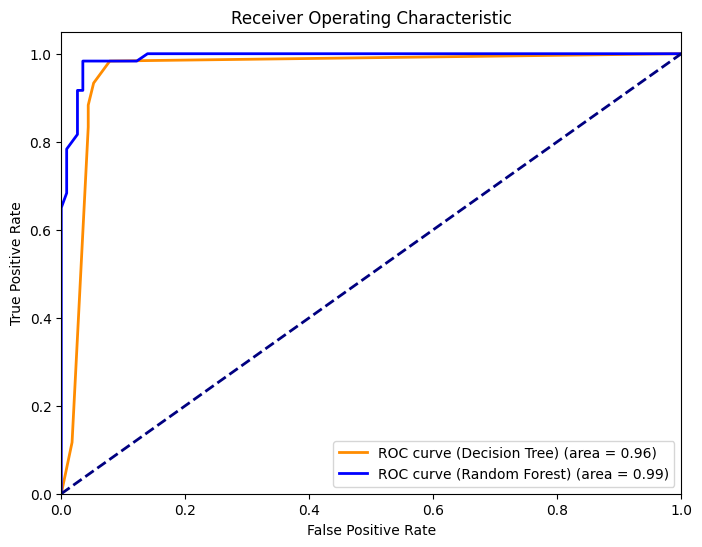

In [ ]:
from sklearn.metrics import roc_curve, auc

#ROC Curve and AUC for Decision Tree
y_pred_proba_tree = tree.predict_proba(X_test)[:, 1] #probabilidad de la clase positiva
fpr_tree, tpr_tree, thresholds_tree = roc_curve(y_test, y_pred_proba_tree)
roc_auc_tree = auc(fpr_tree, tpr_tree)

#ROC Curve and AUC for Random Forest
y_pred_proba_forest = forest.predict_proba(X_test)[:, 1] #probabilidad de la clase positiva
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_test, y_pred_proba_forest)
roc_auc_forest = auc(fpr_forest, tpr_forest)

#Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_tree, tpr_tree, color='darkorange', lw=2, label='ROC curve (Decision Tree) (area = %0.2f)' % roc_auc_tree)
plt.plot(fpr_forest, tpr_forest, color='blue', lw=2, label='ROC curve (Random Forest) (area = %0.2f)' % roc_auc_forest)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()
